In [97]:
# import necessary libraries for geospatial analysis
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import plotly.express as px

In [98]:
# import the data from the data file
oak = pd.read_csv('../Group Data/AllOaksinLACounty.csv')

In [99]:
# convert clo to a geo data frame
geooak = gpd.GeoDataFrame(oak, 
                       crs='epsg:4326',
                       geometry=gpd.points_from_xy(oak.longitude, oak.latitude))

In [100]:
# find the count of all oak species observations in LA County
oak_by_species = oak.value_counts('common_name').reset_index(name='count')

In [101]:
# import geojson for zip codes
zipcodes = gpd.read_file('../Group Data/LA_County_ZIP_Codes.geojson')

In [102]:
# conduct a spatial join
oak_by_zip = gpd.sjoin(zipcodes, geooak)

In [103]:
# count the number of oaks per zip code
oak_counts = oak_by_zip.value_counts('ZIPCODE').reset_index(name='oak_count')

In [104]:
# add the count to the zip codes
oak_by_zip = oak_by_zip.merge(oak_counts, how='left',on='ZIPCODE')

In [105]:
# consolidate oak species into categories
geooak['common_name'] = geooak['common_name'].astype(str)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Coast Live Oak' if 'Coast Live × Interior Live Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Coast Live Oak' if 'coast live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Canyon Live Oak' if 'canyon live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Valley Oak' if 'valley oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'California Scrub Oak' if 'California scrub oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'San Gabriel Oak' if 'San Gabriel oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Engelmann Oak' if 'Engelmann oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Interior Live Oak' if 'interior live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'California black oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Bush Interior Live Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Southern Coast Live Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'southern live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'California Live Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Interior Live Oak' if 'Interior live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Valley Oak' if 'Scrub × Valley Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'island scrub oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'island oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Nuttall's scrub oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'nan' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Holm oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'leather oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'blue oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Shin Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'oaks' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'MacDonald Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Alvord Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Howell's Oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Jolon Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Oracle Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'high-latitude oaks' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Muller's oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Oregon oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Palmer's oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Torrey's Hybrid Oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'pin oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'northern red oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'huckleberry oak' in x else x)

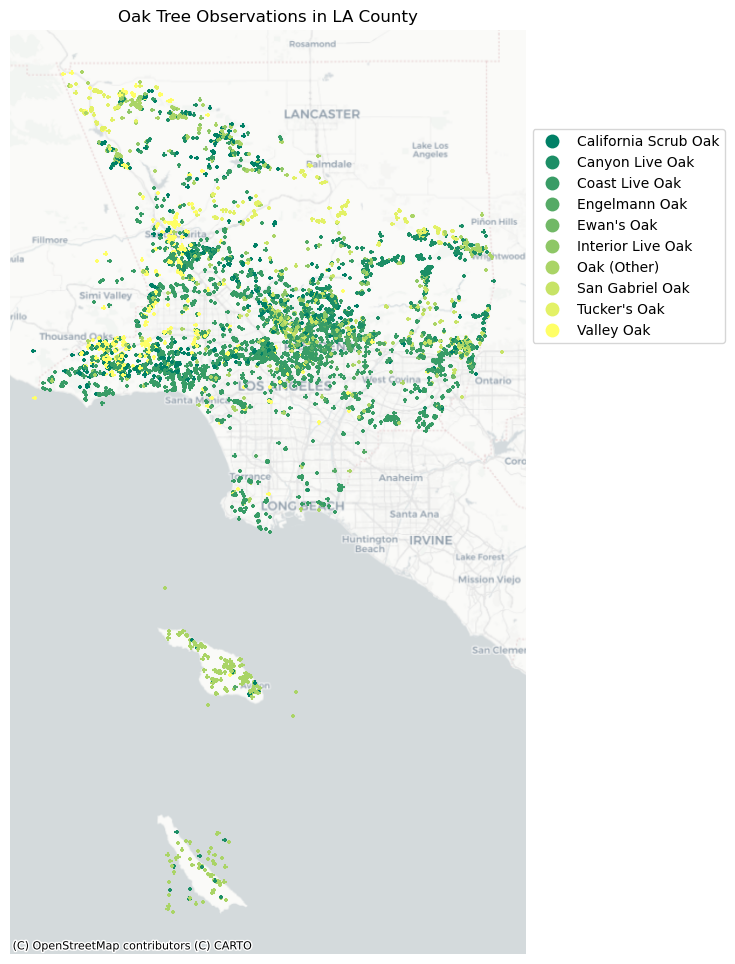

In [108]:
# create a map of the location of oak trees in Los Angeles County by species
fig, ax = plt.subplots(figsize=(12,12))
geooak.plot(ax=ax, 
        marker='+',
        markersize=10,
        column='common_name',
        cmap='summer',
        legend = True,     
        legend_kwds={'loc':'upper left','bbox_to_anchor':(1,.9)})
ax.axis('off')
ax.set_title('Oak Tree Observations in LA County')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326)
plt.savefig('Completed Maps/oaktrees.jpg')

The map included above provides a geospatial visualization of where every observation of an oak tree has been made in Los Angeles County through iNaturalist. While we discussed the potential implications and issuses of use crowd-sourced scientific data in our midterm presentation, this map is still provides a good surface-level visualization of where oak trees are more common, something that we wouldn't get an as exact measurement of by using soil types and/or micro climates. In addition to this, if we transpose this localization data over maps of soil or microclimate type, we may get an idea of which specific species of oak may be more suitable for what category of soil/microclimate (ie. a Coast Live Oak may have different needs than a Valley Oak). More importantly, it will likely be the base of many of the maps we use to compare socioeconomic data with oak tree presence.

From a narrative standpoint, it's also an important step in illustrating our journey of how to understand and study oak tree presence across the county. Without a visualization like this, it would be harder to explain the aforementioned issues with iNaturalist, considering the clear trends it shows of missing data spots in parts of the Angeles National Forest where we would expect higher rates of oak trees and the obvious siting of some trees in middle of the ocean off the Channel Islands.

In [109]:
# import census tracts
census = gpd.read_file('../Group Data/tigerLine-tracts-2022.zip')
census = census.to_crs(crs='EPSG:4326')

In [110]:
# conduct a spatial join
oak_by_tract = gpd.sjoin(census, geooak)

In [111]:
# count the number of oaks per tract
oak_counts1 = oak_by_tract.value_counts('GEOID').reset_index(name='oak_count')

In [112]:
# add the count to the tracts
oak_by_tract = oak_by_tract.merge(oak_counts1, how='left',on='GEOID')

In [113]:
# load census data file for LA County
dem = pd.read_csv('../Group Data/RacialDemographics.csv')
# ensure that the FIPS column is read as a string
dem = pd.read_csv(
    '../Group Data/RacialDemographics.csv',
    dtype=
    {
        'FIPS':str
    }
)

In [114]:
# select columns that have demographic information that will be useful for our analysis
columns_to_keep = ['FIPS',
                   'DP05_0068E',
                   'DP05_0069E',
                   'DP05_0070E',
                   'DP05_0071E',
                   'DP05_0072E',
                   'DP05_0073E',
                   'DP05_0076E',
                   'DP05_0082PE',
                   'Percent Nonwhite']
# create a new dem variable that contains just the aforementioned columns
dem2 = dem[columns_to_keep]

In [115]:
# rename selected columns stored under dem2
dem2.columns = ['GEOID',
'Total Population',
'Total White Population',
'Total Black Population',
'Total Indigenous Population',
'Total Asian Population',
'Total Pacific Islander Population',
'Total Latino Population (Any Race)',
'Percent White',
'Percent Nonwhite']

In [116]:
# setting up data file to only ouptut the necessary columns
census1 = census[['GEOID','geometry']]

In [117]:
census1['GEOID'] = census1['GEOID'].astype('str')
# join together two data sets
tract_dem=census1.merge(dem2,on="GEOID")

/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



AttributeError: PositGron

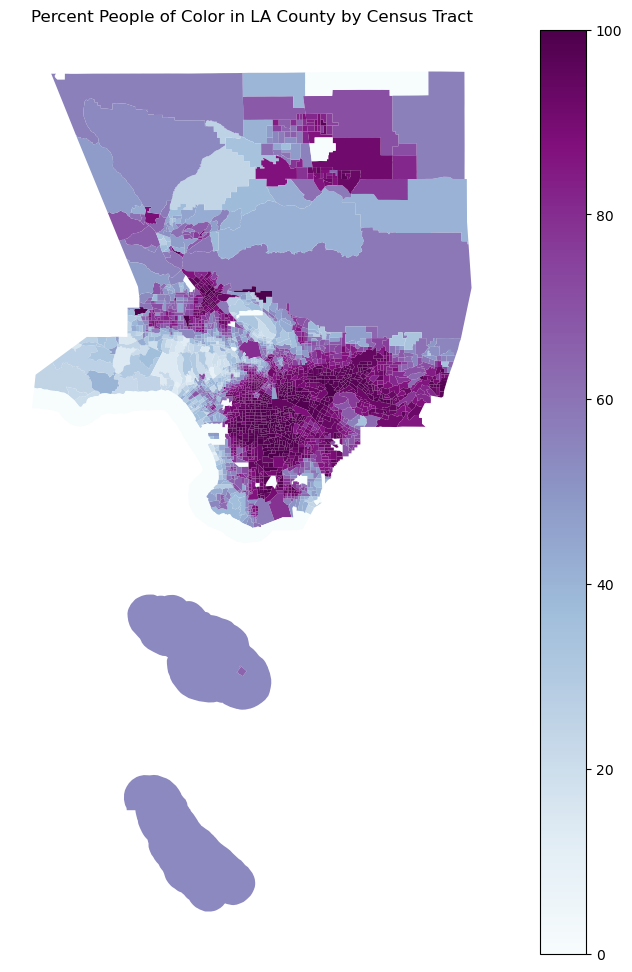

In [118]:
# ouput a map of Los Angeles County showing census tracts by percentage of people of color
fig,ax = plt.subplots(figsize=(12,12))

tract_dem.plot(ax=ax,column='Percent Nonwhite',legend=True,cmap='BuPu')
ax.axis('off')
ax.set_title('Percent People of Color in LA County by Census Tract')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositGron, crs=4326)
plt.savefig('Completed Maps/pocbytract.jpg')

Race has long been considered to be one of the largest determinants both socioeconomic status and health. As a result, being able to represent where in Los Angeles County people of color, who are generally more vulnerable to disasters such as fire, flooding, or extreme heat is something that we thought was essential to visualize if we are looking at any form of social vulnerability. Although this data source doesn't provide anything particularly revelationary (the locations of white residents has been pretty well documented), it does give some context for viewers who may not be familiar with  the Los Angeles region and does tell us from a quick look that disasters like wildfires are not always more prevalent in areas of high POC population, given the recent Palisades Fire.

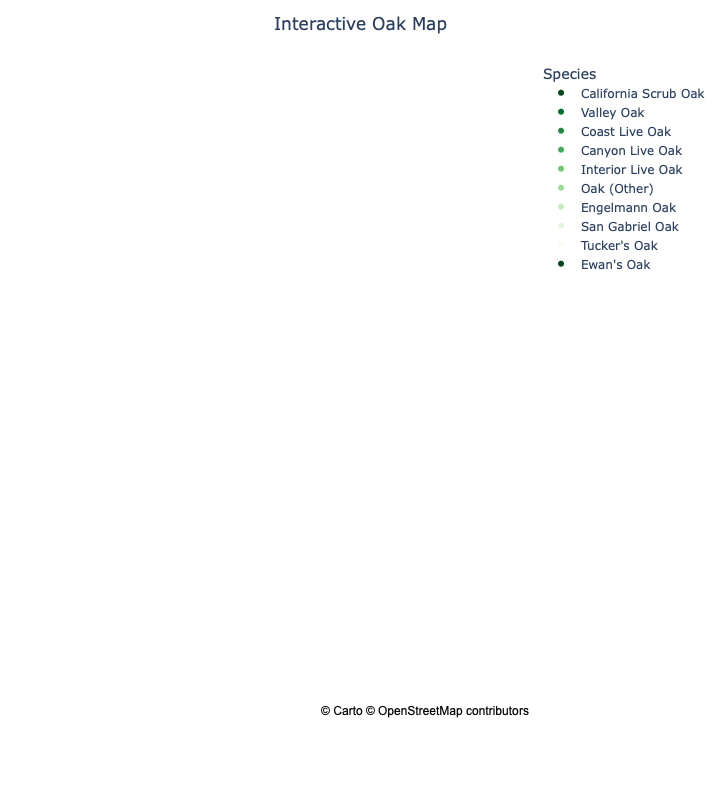

<Figure size 640x480 with 0 Axes>

In [119]:
# create an interactive plot of oak locations
oakpl = px.scatter_mapbox(geooak,
                        lat='latitude',
                        lon='longitude',
                        mapbox_style='carto-positron',
                        color='common_name',
                        color_discrete_sequence=px.colors.sequential.Greens_r,
                        labels={'common_name': 'Species'})
oakpl.update_layout(
    width = 800,
    height = 800,
    title = "Interactive Oak Map",
    title_x=0.5
)
# display the plot
oakpl.show()
plt.savefig('Completed Maps/interactiveoak.tif')

Despite the limitations listed above in the static version of this map, I want to once again reiterate the importance of having an idea of where individual trees are located, even if it is not totally accurate to all trees in Los Angeles. The interactive form of this map makes it much simpler for viewers to zoom into their individual neighborhoods to find trees they may be able to recognize or even seek out coordinates if they'd like to look for it on their own. Given some of the examples of maps we saw from other groups, as well, it seems like this could also be the basis for an interactive map with multiple togglable layers.

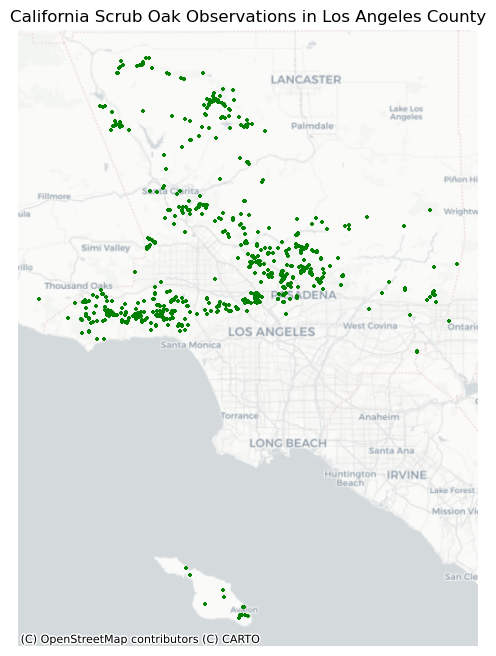

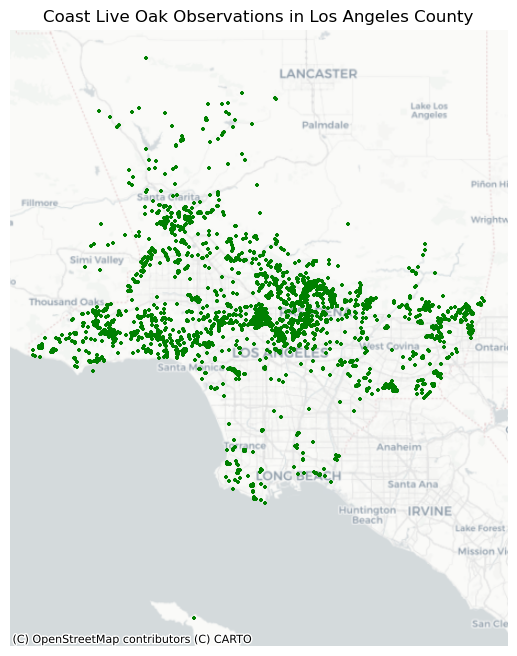

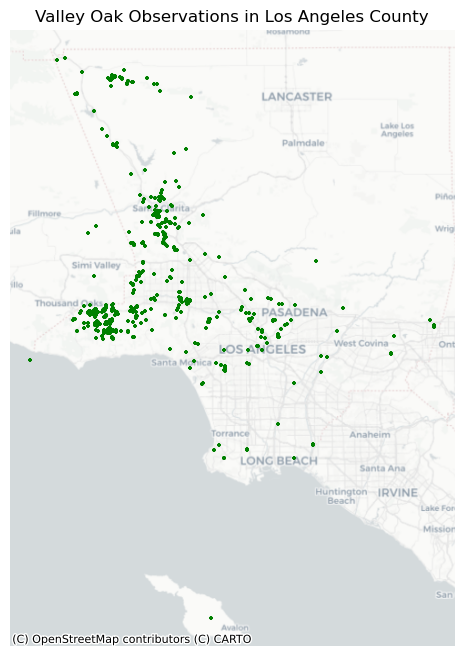

In [124]:
# create a list of zip codes
species = ['California Scrub Oak','Coast Live Oak','Valley Oak']
# create a loop
for name in species:
    fig, ax = plt.subplots(figsize=(8,8))
    geooak[geooak.common_name == name].plot(ax=ax, 
                          marker='+',
                          markersize=5,
                          color='green')
    ax.axis('off')
    ax.set_title(str(name)+' Observations in Los Angeles County')
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326)

The forloop function above allows us to call a specific species of oak tree and map only observations of its members onto a map of Los Angeles County. As previously stated, some species of oak may have different climate and soil needs, allowing us to determine what species can live in what areas of Los Angeles. This preliminary forloop will allows us to use one box of code to graphically represent ever single species and overlay it upon another information layer.